In [154]:
import os
import pandas as pd
from openai import OpenAI

import numpy as np
import json
from dotenv import load_dotenv

import tiktoken
from copy import deepcopy
import re
import glob

import matplotlib.pyplot as plt

repo_dir = "/Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2"
os.chdir(repo_dir)

# Place API_KEY in the .env file
load_dotenv()
# client = OpenAI(api_key=os.environ.get('OPENAI_API_KEY_ASHESH'))
client = OpenAI(api_key=os.environ.get('OPENAI_API_KEY'))

data_dir = os.path.join(repo_dir, "Data/01_bills")
llm_dir = os.path.join(repo_dir, "Data/02_prompts")
os.makedirs(llm_dir, exist_ok=True)

temp_dir = os.path.join(repo_dir, "Temp")
os.makedirs(temp_dir, exist_ok=True)

# Create the MAJOR_TEXT dictionary
MAJOR_TEXT = pd.read_csv(os.path.join(repo_dir, "Data/codebooks/major_topics.csv")).set_index('Major')['MajorText'].to_dict()

fig_dir = os.path.join(repo_dir, "Figures")
os.makedirs(fig_dir, exist_ok=True)

## Generate prompts

### Create `prompting_strategies.csv`

In [155]:
prompting_strategies = pd.DataFrame(data = {
    "PromptingStrategyID": list(range(1, 12+1)),

    "PromptingStrategyName": [
        "Base Prompt", "Base Prompt", 
        "Persona", "Persona", "Persona", "Persona", 
        "Chain-of-Thoughts", "Chain-of-Thoughts", "Chain-of-Thoughts", 
        "Few-Shot", "Few-Shot", "Few-Shot"
        ],

    "Text": [
        None, None, 
        "You are a knowledgeable political analyst. ",
        "Answer this question as if you are a political scientist that studies legislation in the United States Congress. ",
        "Answer this question as if you are an expert in United States politics. ",
        "Answer this question as if you were a helpful research assistant for a political scientist. ",
        "Think carefully. ", 
        "Let's think step by step. Lay out each step. ", 
        "Please provide an explanation for your answer. ",
        None, None, None,
        ],

    "TextLocation": [
        None, None, 
        "before", "before", "before", "before", 
        "after", "after", "after", 
        None, None, None],

    "ExamplesPath": [
        None, None, 
        None, None, None, None, 
        None, None, None, 
        os.path.join(data_dir, "bills_example1.csv"),
        os.path.join(data_dir, "bills_example2.csv"),
        os.path.join(data_dir, "bills_example3.csv")
    ],

    "ResponseFormat": [
        "Fill-in-the-Blanks", "JSON", 
        "JSON", "JSON", "JSON", "JSON", 
        "JSON", "JSON", "JSON", 
        "JSON", "JSON", "JSON"
    ],

    # InputTokens and OuputTokens estimations are based on average run of 100 bills
    "InputTokensAverage": [
        239.96, 242.96, 
        249.96, 261.96, 256.96, 258.96, 
        260.96, 269.96, 265.96, 
        1599.96, 1562.96, 1547.96
    ], 
    "InputTokensSD": [12.53]*12, 
    "OutputTokensAverage": [
        5.96, 19, 
        19, 19, 19, 19, 
        47.56, 47.47, 48.36, 
        15, 15, 15
    ], 
    "OutputTokensSD": [
        0.2, 0.00, 
        0.00, 0.00, 0.00, 0.00, 
        4.41, 4.72, 5.29, 
        0.00, 0.00, 0.00]
})
prompting_strategies.insert(loc=4, column="AddExamples", value=prompting_strategies["PromptingStrategyName"] == "Few-Shot")
prompting_strategies["AddExplanation"] = prompting_strategies["PromptingStrategyName"] == "Chain-of-Thoughts"

n = len(prompting_strategies)
prompting_strategies = pd.concat([prompting_strategies, prompting_strategies], ignore_index=True)
prompting_strategies["Model"] = ["gpt-3.5-turbo-0125"]*n + ["gpt-4o-2024-05-13"]*n

# ModelInputCost_perToken = [0.50/1e6]*n + [5.00/1e6]*n # + [0.150/1e6]*n
# ModelOutputCost_perToken = [1.50/1e6]*n + [15.0/1e6]*n # + [0.60/1e6]*n
# prompting_strategies["TotalCostAverage_per10KBills"] = (
#     (prompting_strategies["InputTokensAverage"] * ModelInputCost_perToken) + 
#     (prompting_strategies["OutputTokensAverage"] * ModelOutputCost_perToken)) * 10e3

# prompting_strategies.insert(loc=0, column="PromptingStrategyID", value = list(range(1, len(prompting_strategies)+1)))

prompting_strategies["Temperature"] = 0 
prompting_strategies.to_csv(os.path.join(llm_dir, "prompting_strategies.csv"), index=False, float_format='%.2f')

## Create `prompts.jsonl`

In [156]:
CATEGORIES = "\n".join([f"{int(major)}. {text}" for major, text in MAJOR_TEXT.items()])

QUESTION =f"""Here is a description of a bill introduced in the U.S. Congress:
"{{0}}"

Please classify this description into one of the following categories:
{CATEGORIES}
"""

ANSWER_JSON = f"""Output a JSON object structured like: {{{{
    "Category": an integer from {min(MAJOR_TEXT.keys())} to {max(MAJOR_TEXT.keys())} that best represents the bill category,
    "Confidence": confidence level in the bill classification as a number between 0 to 1 with 2 decimal places
}}}}
"""

ANSWER_JSON_EXPLANATION = f"""Output a JSON object structured like: {{{{
    "Category": an integer from {min(MAJOR_TEXT.keys())} to {max(MAJOR_TEXT.keys())} that best represents the bill category,
    "Confidence": confidence level in the bill classification as a number between 0 to 1 with 2 decimal places,
    "Explanation": a one-sentence explanation for your chosen bill category
}}}}
"""

ANSWER_BLANKS = f"""Write your answer as:
____ (fill in with an integer from {min(MAJOR_TEXT.keys())} to {max(MAJOR_TEXT.keys())} that best represents the bill category),
____ (fill in with confidence level in the bill classification as a number between 0 to 1 with 2 decimal places)
"""

ANSWER_BLANKS_EXPLANATION = f"""Write your answer as:
____ (fill in with an integer from {min(MAJOR_TEXT.keys())} to {max(MAJOR_TEXT.keys())} that best represents the bill category),
____ (fill in with confidence level in the bill classification as a number between 0 to 1 with 2 decimal places),
____ (fill in with a one-sentence explanation for your chosen bill category)
"""

In [157]:
def create_content_user(strategy):
    question = QUESTION + "\n"
    if strategy["TextLocation"] == "before":
        question = strategy["Text"] + question
    elif strategy["TextLocation"] == "after":
        question = question + strategy["Text"]

    if strategy["ResponseFormat"]=="JSON":
        if strategy["AddExplanation"]:
            answer = ANSWER_JSON_EXPLANATION
        else:
            answer = ANSWER_JSON
    else:
        if strategy["AddExplanation"]:
            answer = ANSWER_BLANKS_EXPLANATION
        else:
            answer = ANSWER_BLANKS

    content = question + answer
    return content

def create_content_assistant(strategy, category, confidence, explanation=None):
    if strategy["ResponseFormat"]=="JSON":
        if strategy["AddExplanation"]:

            if explanation is None:
                raise Exception("AddExplanation=True but explanation=None. You need to pass a string to explanation variable")
            
            correct_answer = {
                "Category": category,
                "Confidence": np.round(confidence, decimals=2),
                "Explanation": explanation
            }
        else:
            correct_answer = {
                "Category": category,
                "Confidence": np.round(confidence, decimals=2)
            }
        content = json.dumps(correct_answer)

    else:
        if strategy["AddExplanation"]:

            if explanation is None:
                raise Exception("AddExplanation=True but explanation=None. You need to pass a string to explanation variable")
            
            correct_answer = "%d, %.2f, %s\n" % (category, confidence, explanation)
        else:
            correct_answer = "%d, %.2f\n" % (category, confidence)
        content = correct_answer

    return content

def create_messages(strategy, min_confidence, max_confidence=1, examples_via_system=True):
    messages = []

    if strategy["AddExamples"]:
        bills_examples = pd.read_csv(strategy["ExamplesPath"])
        
        for _, bill in bills_examples.iterrows():
            message_user_content = create_content_user(strategy).format(bill["Description"])

            if examples_via_system:
                message_user = {"role": "system", "name": "example_user", "content": message_user_content}
            else:
                message_user = {"role": "user", "content": message_user_content}
            messages.append(message_user)

            message_assistant_content = create_content_assistant(strategy, category=bill["Major"], confidence=np.random.uniform(min_confidence, max_confidence))
            if examples_via_system:
                message_assistant = {"role": "system", "name": "example_assistant", "content": message_assistant_content}
            else:
                message_assistant = {"role": "assistant", "content": message_assistant_content}
            messages.append(message_assistant)
    
    message_user_content = create_content_user(strategy)
    message_user = {"role": "user", "content": message_user_content}
    messages.append(message_user)
    return messages

def count_tokens(messages, model="gpt-3.5-turbo"):
    encoding = tiktoken.encoding_for_model(model)
    tokens_per_message = 3
    tokens_per_name = 1
    num_tokens = 0
    for message in messages:
        num_tokens += tokens_per_message
        for key, value in message.items():
            num_tokens += len(encoding.encode(value))
            if key == "name":
                num_tokens += tokens_per_name
    num_tokens += 3  # every reply is primed with <|start|>assistant<|message|>
    return num_tokens

In [158]:
prompting_strategies = pd.read_csv(os.path.join(llm_dir, "prompting_strategies.csv"))
bills = pd.read_csv(os.path.join(data_dir, f"bills_10k.csv"))
bills_15 = pd.read_csv(os.path.join(data_dir, "bills_15.csv"))
prompts_path = os.path.join(llm_dir, f"prompts.jsonl")

prompting_strategies_json = []
for _, strategy in prompting_strategies.iterrows():
    strategy_json = {
        "PromptingStrategyID": strategy["PromptingStrategyID"],
        "PromptingStrategyName": strategy["PromptingStrategyName"],
        "ResponseFormat": strategy["ResponseFormat"],
        "AddExplanation": strategy["AddExplanation"],
        "AddExamples": strategy["AddExamples"],
        "Model": strategy["Model"], 
        "Temperature": strategy["Temperature"],
        "Messages": create_messages(strategy, min_confidence=0.9, max_confidence=1, examples_via_system=True)
    }
    prompting_strategies_json.append(strategy_json)
    
prompting_strategies_json = pd.json_normalize(prompting_strategies_json)

id = 0
prompts = []
for _, bill in bills.iterrows():
    for _, strategy in prompting_strategies_json.iterrows():
        
        # add bill to last used message
        bill_messages = deepcopy(strategy["Messages"])
        bill_messages[-1]["content"] = bill_messages[-1]["content"].format(bill["Description"])
        
        input_tokens = count_tokens(bill_messages, strategy['Model'])
        output_tokens = 0

        id = id + 1
        prompt = {
            "ID": id,
            "BillID": bill["BillID"],
            "PromptingStrategyID": strategy["PromptingStrategyID"],
            "Description": bill["Description"],
            "PromptingStrategyName": strategy["PromptingStrategyName"],
            "ResponseFormat": strategy["ResponseFormat"],
            "AddExplanation": strategy["AddExplanation"],
            "AddExamples": strategy["AddExamples"],
            "Model": strategy["Model"],
            "Temperature": strategy["Temperature"],
            "Major": bill["Major"],
            "MajorText": bill["MajorText"],
            "InputTokens": input_tokens,
            "Messages": bill_messages
        }
        prompts.append(prompt)


with open(prompts_path, "w") as f:
    for prompt in prompts:
        f.write(json.dumps(prompt) + "\n")
print(f"Saved {prompts_path}")

Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Data/02_prompts/prompts.jsonl


## Estimate Cost using Batch API

In [159]:
PRICES = {
    'gpt-3.5-turbo-0125': {
        'input': 0.25/1e6, 
        'output': 0.75/1e6
    },
    'gpt-4o-2024-05-13': {
        'input': 2.5/1e6, 
        'output': 7.5/1e6
    },
}

def estimate_cost(prompts):
    prompting_strategies = pd.read_csv(os.path.join(llm_dir, "prompting_strategies.csv"))[["PromptingStrategyID","Model", "OutputTokensAverage"]]
    prompts = prompts[["PromptingStrategyID","Model", "InputTokens"]]
    prompts = prompts.merge(prompting_strategies, on=["PromptingStrategyID", "Model"], validate="m:1")
    
    input_tokens_cost = prompts["InputTokens"] * prompts["Model"].apply(lambda x: PRICES.get(x).get('input'))
    output_tokens_cost = prompts["OutputTokensAverage"] * prompts["Model"].apply(lambda x: PRICES.get(x).get('output'))
    total_cost = (input_tokens_cost + output_tokens_cost).sum()
    return total_cost

prompts = pd.read_json(os.path.join(llm_dir, f"prompts.jsonl"), lines=True)
print(f"Estimated cost of running {os.path.basename(prompts_path)} is ${estimate_cost(prompts):.2f}")

Estimated cost of running prompts.jsonl is $220.97


### Create `prompts_batched.jsonl`

In [131]:
prompts_path = os.path.join(llm_dir, f"prompts.jsonl")
prompts = pd.read_json(prompts_path, lines=True)

for model in prompts["Model"].unique(): 
    prompts_model = prompts[prompts["Model"]==model].reset_index()

    prompts_batched = []
    part = 0
    for i, prompt in prompts_model.iterrows():
        prompt_batched = {
                "custom_id": "ID_" + str(prompt["ID"]),
                "method": "POST",
                "url": "/v1/chat/completions",
                "body": {
                    "model": prompt["Model"],
                    "temperature": prompt["Temperature"],
                    "response_format": {"type": "json_object"} if (prompt["ResponseFormat"]=="JSON") else None,
                    "messages": prompt["Messages"],
                }
            }
        prompts_batched.append(prompt_batched)

        if ((i==(12e3-1)) | (len(prompts_batched)==50e3) | (i==(len(prompts_model)-1))):
            part = part + 1
            prompts_batched_path = os.path.join(temp_dir, f"prompts_batched_{model}_part{part}.jsonl")
            with open(prompts_batched_path, "w") as f:
                for prompt_batched in prompts_batched:
                    f.write(json.dumps(prompt_batched) + "\n")
                print(f"Saved {prompts_batched_path}")
            prompts_batched = []


Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Temp/prompts_batched_gpt-3.5-turbo-0125_part1.jsonl
Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Temp/prompts_batched_gpt-3.5-turbo-0125_part2.jsonl
Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Temp/prompts_batched_gpt-3.5-turbo-0125_part3.jsonl
Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Temp/prompts_batched_gpt-3.5-turbo-0125_part4.jsonl
Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Temp/prompts_batched_gpt-4o-2024-05-13_part1.jsonl
Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Temp/prompts_batched_gpt-4o-2024-05-13_part2.jsonl
Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Temp/prompts_batched_gpt-4o-2024-05-13_part3.jsonl
Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Temp/prompts_batched_gpt-4o-2024-05-13_part4.jsonl


## Generate responses

In [133]:
batches = {}

prompts_batched_paths = glob.glob(os.path.join(temp_dir, f'prompts_batched_*.jsonl'))

for prompts_batched_path in prompts_batched_paths:
    batch_input_file = client.files.create(
        file = open(prompts_batched_path, "rb"),
        purpose = "batch"
    )
    batch_input_file_id = batch_input_file.id
    batch = client.batches.create(
            input_file_id = batch_input_file_id,
            endpoint = "/v1/chat/completions",
            completion_window = "24h",
            metadata = {"description": f"{os.path.basename(prompts_batched_path)}"}
        )
    
    # Regex pattern to match the part number
    pattern = r'_part(\d+)'

    # Extract the part numbers
    part = int(re.search(pattern, prompts_batched_path).group(1))

    batches[os.path.basename(prompts_batched_path)] = {
        'part': part,
        'id': batch.id
    }

batches

{'prompts_batched_gpt-3.5-turbo-0125_part2.jsonl': {'part': 2,
  'id': 'batch_7gkh8bFrNU2Q1HvzQ8wyRydJ'},
 'prompts_batched_gpt-3.5-turbo-0125_part4.jsonl': {'part': 4,
  'id': 'batch_yhJGdOsNrqKhUFsWiKVlmJl8'},
 'prompts_batched_gpt-3.5-turbo-0125_part3.jsonl': {'part': 3,
  'id': 'batch_Ownoc4Uzv692efSN8XXZWUEV'},
 'prompts_batched_gpt-3.5-turbo-0125_part1.jsonl': {'part': 1,
  'id': 'batch_yX3CXJ50MMhka5AD7omsHW2s'},
 'prompts_batched_gpt-4o-2024-05-13_part4.jsonl': {'part': 4,
  'id': 'batch_XEZMzN8bvFkyY28XKn33GEuz'},
 'prompts_batched_gpt-4o-2024-05-13_part2.jsonl': {'part': 2,
  'id': 'batch_9sXS7RHIXkcNS1DGTuNjtHSI'},
 'prompts_batched_gpt-4o-2024-05-13_part1.jsonl': {'part': 1,
  'id': 'batch_VKYQ2FjxkOPkIXo7DApLZZZQ'},
 'prompts_batched_gpt-4o-2024-05-13_part3.jsonl': {'part': 3,
  'id': 'batch_NiFIcgfxmakWFfl7a7Ka6z0N'}}

In [58]:
# Original Batches
batches = {
    'prompts_batched_gpt-3.5-turbo-0125_part1.jsonl': {'part': 1, 'id': 'batch_tSVIpwOEqYLYIxrzneZ38Cf8'}, #12e3, this was the 1000 bill run, , prompts_batched_1000_gpt-3.5-turbo-0125.json
    'prompts_batched_gpt-3.5-turbo-0125_part2.jsonl': {'part': 2, 'id': 'batch_6yCzX3zUgi7xKFzWx7Y3wCih'}, #50e3, prompts_batched_9000_gpt-3.5-turbo-0125_part1.json
    'prompts_batched_gpt-3.5-turbo-0125_part3.jsonl': {'part': 3, 'id': 'batch_zK9n9beqzKH84y8k45IO4Hep'}, #50e3, prompts_batched_9000_gpt-3.5-turbo-0125_part2.json
    'prompts_batched_gpt-3.5-turbo-0125_part4.jsonl': {'part': 4, 'id': 'batch_pvocTdpKJAeylK6tdHxvpZmu'}, #8e3, prompts_batched_9000_gpt-3.5-turbo-0125_part3.json
    'prompts_batched_gpt-4o-2024-05-13_part1.jsonl':  {'part': 1, 'id': 'batch_Qi4lin1f66j96pho3ofhRxyl'}, #12e3, this was the 1000 bill run, prompts_batched_1000_gpt-4o.json
    'prompts_batched_gpt-4o-2024-05-13_part2.jsonl':  {'part': 2, 'id': 'batch_k0XxH5uZU78uyloLs8IYIBwh'}, #50e3, prompts_batched_9000_gpt-4o_part1.json
    'prompts_batched_gpt-4o-2024-05-13_part3.jsonl':  {'part': 3, 'id': 'batch_0IR9IRoYYJb6TYYvvN8XqXk2'}, #50e3, prompts_batched_9000_gpt-4o_part2.json
    'prompts_batched_gpt-4o-2024-05-13_part4.jsonl':  {'part': 4, 'id': 'batch_8EFmBWRWBFJuStCPbO26rhQ3'}, #8e3, prompts_batched_9000_gpt-4o_part3.json
    }

In [ ]:
# Check status of all batches
for file in batches:
    id = batches[file]['id']
    batch_status = client.batches.retrieve(id)
    print(f"{file:>52s}: {batch_status.status}")

In [ ]:
for file in batches:
    batch_id = batches[file]['id']
    part = batches[file]['part']
    batch_status = client.batches.retrieve(batch_id)
    
    if batch_status.status != "completed":
        print(f"Skipping incomplete file = {file}, Batch ID = {batch_id}")
        continue
    
    output_file_id = batch_status.output_file_id
    responses_batched = client.files.content(output_file_id)

    responses_batched_path = os.path.join(temp_dir, file.replace("prompts", "responses"))
    responses_batched.write_to_file(responses_batched_path)

    # if not part 1, we correct the ID as it shouldn't start from 1
    if (part!=1):
        responses_batched = pd.read_json(responses_batched_path, lines=True)
        responses_batched["custom_id"] = responses_batched["custom_id"].apply(lambda x: "ID_" + str(int(x[3:]) + int(1000*24))) 
        responses_batched.to_json(responses_batched_path, orient='records', lines=True)

    print(f"Saved raw responses at {responses_batched_path}")

## Decode Responses

In [160]:
prompts_path = os.path.join(llm_dir, f"prompts.jsonl")
responses_path = os.path.join(llm_dir, f"responses.jsonl")

responses_batched = []
for responses_batched_path in sorted(glob.glob(os.path.join(temp_dir, f'responses_batched_*.jsonl'))):
    responses_batched_file = pd.read_json(responses_batched_path, lines=True)
    print(f"Loaded {responses_batched_path}, n = {len(responses_batched_file)}")
    responses_batched_file["ID"] = responses_batched_file["custom_id"].apply(lambda x: int(x[3:]))
    responses_batched.append(responses_batched_file)

responses_batched = pd.concat(responses_batched)
print(f"Appended all responses, n = {len(responses_batched)}")

prompts = pd.read_json(prompts_path, lines=True)[["ID", "BillID", "ResponseFormat", "AddExplanation"]]
responses_batched = responses_batched.merge(prompts, on="ID")
responses_batched.set_index("ID", inplace=True, drop=False)
responses_batched.sort_index(inplace=True)

responses = []
for _, response_batched in responses_batched.iterrows(): 

    response_text = response_batched.response["body"]["choices"][0]["message"]["content"]

    if response_batched["ResponseFormat"]=="JSON":
        temp = json.loads(response_text)
        major = int(temp["Category"])
        response = {
            "ID": response_batched["ID"],
            "MajorLLM": major,
            "MajorTextLLM": MAJOR_TEXT[major],
            "ConfidenceLLM": float(temp["Confidence"]),
            "ExplanationLLM": temp["Explanation"] if response_batched["AddExplanation"] else None
        }

    else:
        single_entry_pattern = r'^(\d+)\s*[,]{0,1}\s*[\r\n]{0,1}\s*([0-9]\.[0-9]{2})\s*[,]{0,1}[\r\n]{0,1}?\s*(.*)?$'
        multiple_entries_pattern = r'((\d+)\s*\.\s*([\d\.]+)\s*\n)' 

        if re.match(single_entry_pattern, response_text):
            match = re.match(single_entry_pattern, response_text)
            major = int(match.group(1))
            response = {
                "ID": response_batched["ID"],
                "MajorLLM": major,
                "MajorTextLLM": MAJOR_TEXT[major],
                "ConfidenceLLM": float(match.group(2)),
                "ExplanationLLM": match.group(3) if response_batched["AddExplanation"] else None
            }
        elif re.findall(multiple_entries_pattern, response_text):
            print("hi")
            matches = re.findall(multiple_entries_pattern, response_text)
            match = max(matches, key=lambda x: float(x[2]))
            major = int(match[1])
            explanation = re.split('\n', response_text)[-1]
            response = {
                "ID": response_batched["ID"],
                "MajorLLM": major,
                "MajorTextLLM": MAJOR_TEXT[major],
                "ConfidenceLLM": float(match[2]),
                "ExplanationLLM": explanation if response_batched["AddExplanation"] else None
            }

    response["InputTokens"] = int(response_batched.response["body"]["usage"]["prompt_tokens"])
    response["OutputTokens"] = int(response_batched.response["body"]["usage"]["completion_tokens"])
    responses.append(response)

with open(responses_path, "w") as f:
    for response in responses:
        f.write(json.dumps(response) + "\n")
print(f"Saved {responses_path}")

Loaded /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Temp/responses_batched_gpt-3.5-turbo-0125_part1.jsonl, n = 12000
Loaded /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Temp/responses_batched_gpt-3.5-turbo-0125_part2.jsonl, n = 50000
Loaded /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Temp/responses_batched_gpt-3.5-turbo-0125_part3.jsonl, n = 50000
Loaded /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Temp/responses_batched_gpt-3.5-turbo-0125_part4.jsonl, n = 8000
Loaded /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Temp/responses_batched_gpt-4o-2024-05-13_part1.jsonl, n = 12000
Loaded /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Temp/responses_batched_gpt-4o-2024-05-13_part2.jsonl, n = 50000
Loaded /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Temp/responses_batched_gpt-4o-2024-05-13_part3.jsonl, n = 50000
Loaded /Users/haya1/Documents/L

In [162]:
# Merge prompts and responses datasets
bills_path = os.path.join(data_dir, f"bills_10k.csv")
prompts_path = os.path.join(llm_dir, f"prompts.jsonl")
responses_path = os.path.join(llm_dir, f"responses.jsonl")

bills_prompts_responses_path = os.path.join(llm_dir, f"bills_prompts_responses.csv")

bills = pd.read_csv(bills_path)
prompts = pd.read_json(prompts_path, lines=True)
prompts.drop(columns=["Messages", "InputTokens"], inplace=True)
responses = pd.read_json(responses_path, lines=True)

bills_prompts_responses = prompts.merge(responses, on="ID", validate="1:1").merge(bills, on="BillID", validate="m:1", suffixes=("","_y"))
n_bills = len(bills_prompts_responses['BillID'].unique())
n_prompts = len(bills_prompts_responses)
print(f"Merged bills, prompts and responses, n_bills = {n_bills}, n_prompts = {n_prompts}")

# columns2keep = [not col.endswith('_y') for col in bills_prompts_responses.columns]

columns2keep =  [
    "ID", "BillID", "PromptingStrategyID", "Description", "PromptingStrategyName", "ResponseFormat", 
    "AddExplanation", "AddExamples", "Model", "Temperature", "Major", "MajorText", "MajorLLM", 
    "MajorTextLLM", "ConfidenceLLM", "ExplanationLLM", "Year", "Party", "DW1", "DW1_NA", "Chamber", "Postal"
    ]
bills_prompts_responses = bills_prompts_responses.loc[:, columns2keep]
print(f"Dropped unused/duplicated columns.")

bills_prompts_responses.to_csv(bills_prompts_responses_path, index=False)
print(f"Saved merged data at {bills_prompts_responses_path}")

bills_prompts_responses.head()

Merged bills, prompts and responses, n_bills = 10000, n_prompts = 240000
Dropped unused/duplicated columns.
Saved merged data at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills_v2/Data/02_prompts/bills_prompts_responses.csv


,ID,BillID,PromptingStrategyID,Description,PromptingStrategyName,ResponseFormat,AddExplanation,AddExamples,Model,Temperature,...,MajorLLM,MajorTextLLM,ConfidenceLLM,ExplanationLLM,Year,Party,DW1,DW1_NA,Chamber,Postal
0,1,88-S-1173,1,A bill to change the name of Short Mountain lo...,Base Prompt,Fill-in-the-Blanks,False,False,gpt-3.5-turbo-0125,0,...,20,Public Lands and Water Management,0.95,None,1963,Democrat,-0.243,-0.243,Senate,OK
1,2,88-S-1173,2,A bill to change the name of Short Mountain lo...,Base Prompt,JSON,False,False,gpt-3.5-turbo-0125,0,...,20,Public Lands and Water Management,0.95,None,1963,Democrat,-0.243,-0.243,Senate,OK
2,3,88-S-1173,3,A bill to change the name of Short Mountain lo...,Persona,JSON,False,False,gpt-3.5-turbo-0125,0,...,20,Public Lands and Water Management,0.85,None,1963,Democrat,-0.243,-0.243,Senate,OK
3,4,88-S-1173,4,A bill to change the name of Short Mountain lo...,Persona,JSON,False,False,gpt-3.5-turbo-0125,0,...,20,Public Lands and Water Management,0.95,None,1963,Democrat,-0.243,-0.243,Senate,OK
4,5,88-S-1173,5,A bill to change the name of Short Mountain lo...,Persona,JSON,False,False,gpt-3.5-turbo-0125,0,...,20,Public Lands and Water Management,0.95,None,1963,Democrat,-0.243,-0.243,Senate,OK


## Unique MajorLLM

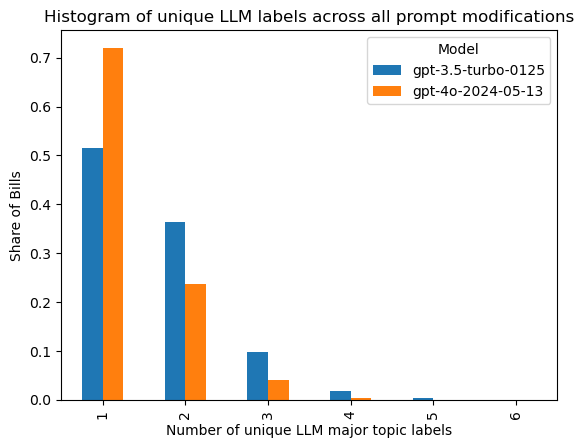

In [137]:
# stat = bills_prompts_responses.groupby(["BillID"]).agg(
#     UniqueMajorLLM = ("MajorLLM", "nunique")
#     ).reset_index()
# labels, counts = np.unique(stat["UniqueMajorLLM"], return_counts=True)
# shares = counts/n_bills
# plt.bar(labels, shares, align='center')
# plt.gca().set_xticks(labels)
# plt.title(f'Histogram of unique MajorLLM per bill')
# plt.xlabel('Number of unique MajorLLM')
# plt.ylabel('Share of Bills')
# plt.show()

stat = bills_prompts_responses.groupby(["Model","BillID"]).agg(
        UniqueMajorLLM = ("MajorLLM", "nunique")
        ).groupby(["Model","UniqueMajorLLM"]).size().reset_index(name='Count')
stat['Share'] = stat['Count']/n_bills
stat.pivot(index='UniqueMajorLLM', columns='Model', values='Share').plot(
    kind="bar", 
    title=f"Histogram of unique LLM labels across all prompt modifications",
    xlabel="Number of unique LLM major topic labels",
    ylabel="Share of Bills")

plt.savefig(os.path.join(fig_dir, 'A histogram of unique LLM labels across all prompt modifications.png'))

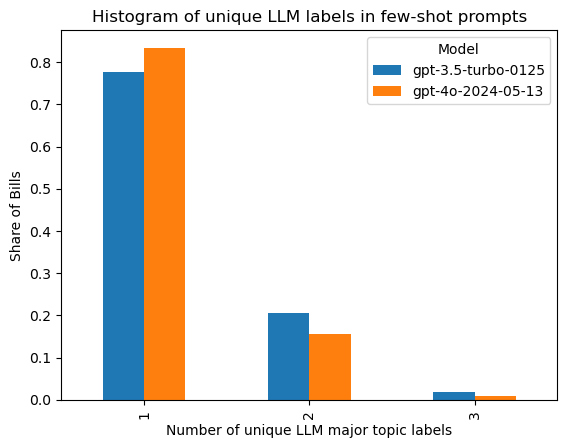

In [138]:
stat = bills_prompts_responses[bills_prompts_responses["PromptingStrategyName"]=="Few-Shot"].groupby(["Model","BillID"]).agg(
        UniqueMajorLLM = ("MajorLLM", "nunique")
        ).groupby(["Model","UniqueMajorLLM"]).size().reset_index(name='Count')
stat['Share'] = stat['Count']/n_bills
stat.pivot(index='UniqueMajorLLM', columns='Model', values='Share').plot(
    kind="bar", 
    title=f"Histogram of unique LLM labels in few-shot prompts",
    xlabel="Number of unique LLM major topic labels",
    ylabel="Share of Bills")

plt.savefig(os.path.join(fig_dir, 'A histogram of unique LLM labels in few-shot prompts only.png'))

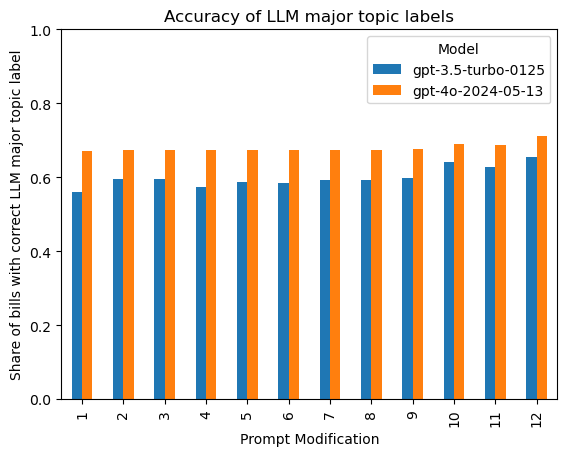

In [139]:
bills_prompts_responses = pd.read_csv(bills_prompts_responses_path)
bills_prompts_responses["CorrectMajorLLM"] = bills_prompts_responses["Major"] == bills_prompts_responses["MajorLLM"]
stat = bills_prompts_responses.groupby(["PromptingStrategyID", "PromptingStrategyName", "Model"]).agg(
    ShareCorrectMajorLLM = ("CorrectMajorLLM", "mean")
).reset_index().pivot(index='PromptingStrategyID', columns='Model', values='ShareCorrectMajorLLM').plot(
    kind="bar", 
    title=f'Accuracy of LLM major topic labels',
    xlabel='Prompt Modification',
    ylabel='Share of bills with correct LLM major topic label',
    ylim=(0,1)) 

plt.savefig(os.path.join(fig_dir, 'Accuracy of LLM major topic labels.png'))